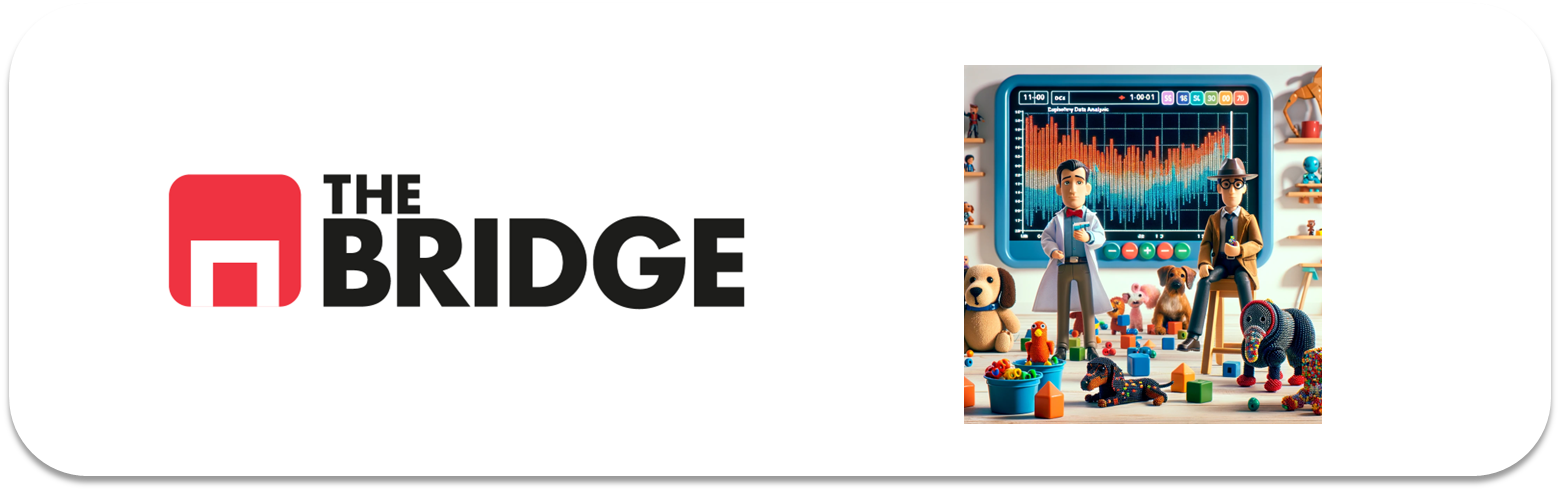

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from bootcampviztools import (plot_categorical_relationship_fin, 
                               pinta_distribucion_categoricas,
                               plot_grouped_histograms,
                               plot_grouped_boxplots, 
                               plot_combined_graphs,
                               plot_categorical_numerical_relationship,
                               grafico_dispersion_con_correlacion)

from scipy.stats import chi2_contingency, mannwhitneyu


## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [2]:
df_titanic = pd.read_csv("./data/titanic.csv")
df = df_titanic.copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [3]:
df.drop(columns=["deck", "survived", "pclass", "embarked"], inplace=True)

### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [4]:
df["family_members"] = df["parch"] + df["sibsp"]
df.drop(columns=["parch", "sibsp"], inplace=True)

### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [5]:
moda_embark = df["embark_town"].mode()[0]
df.loc[df["embark_town"].isna(), "embark_town"] = moda_embark


### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [6]:
df["age_imputed"] = df["age"].isna()


for grupo in df["who"].unique():
    mediana = df.loc[df["who"] == grupo, "age"].median()
    df.loc[(df["who"] == grupo) & df["age_imputed"], "age"] = mediana

### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

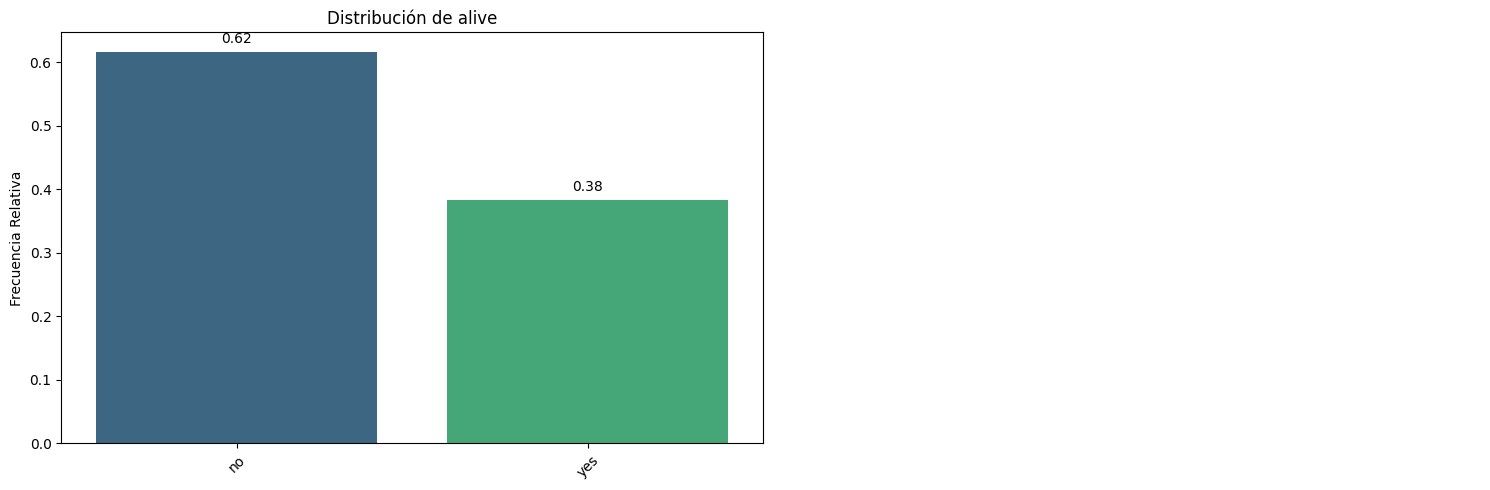

In [7]:
pinta_distribucion_categoricas(df, ["alive"], relativa=True, mostrar_valores=True)



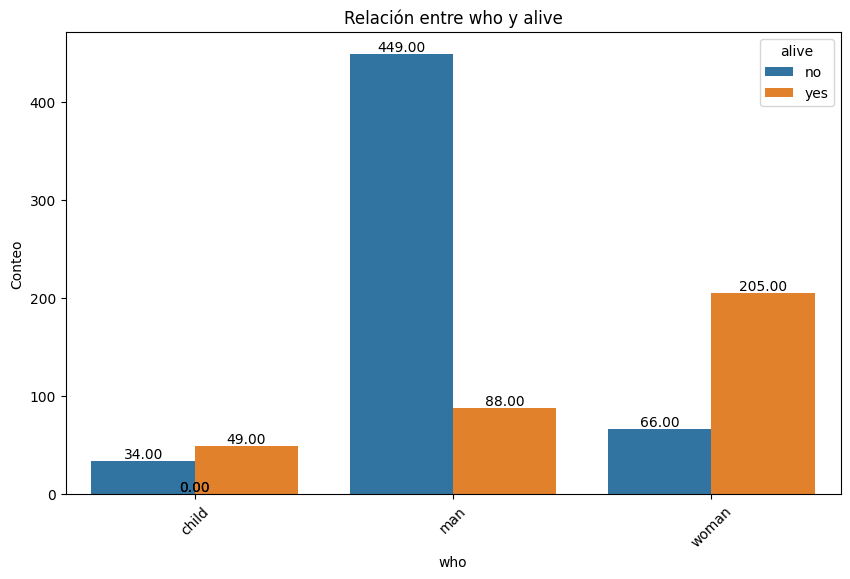

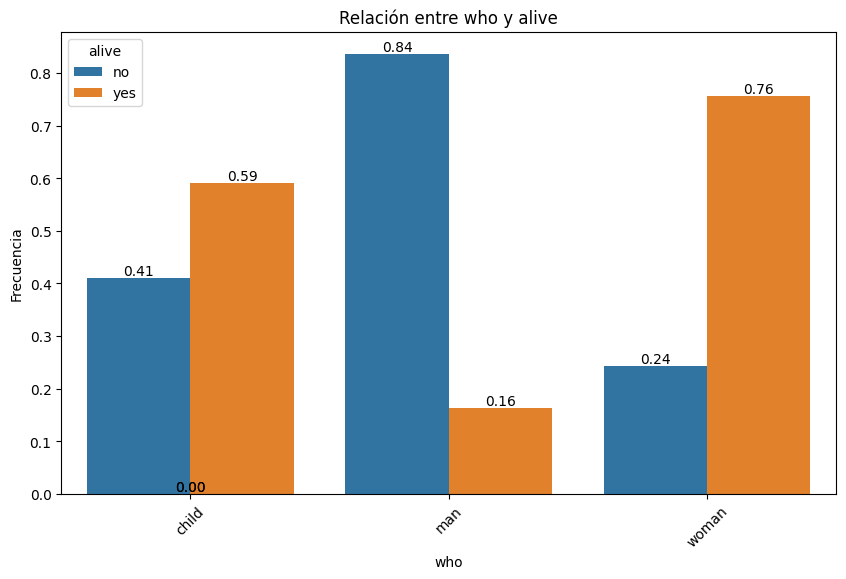

In [8]:
plot_categorical_relationship_fin(df, "who", "alive", show_values=True)
plot_categorical_relationship_fin(df, "who", "alive", relative_freq=True, show_values=True)

In [9]:
tabla = pd.crosstab(df["alive"], df["who"])
chi2, p_value, dof, expected = chi2_contingency(tabla)
print(f"Chi2: {chi2:.2f} | p-value: {p_value:.4f}")
print("¿Relación significativa?", p_value < 0.05)

Chi2: 283.92 | p-value: 0.0000
¿Relación significativa? True


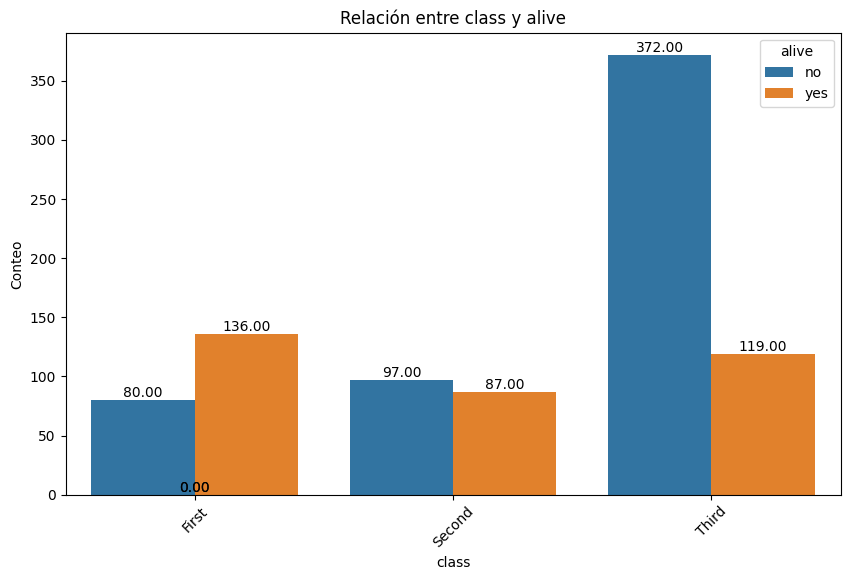

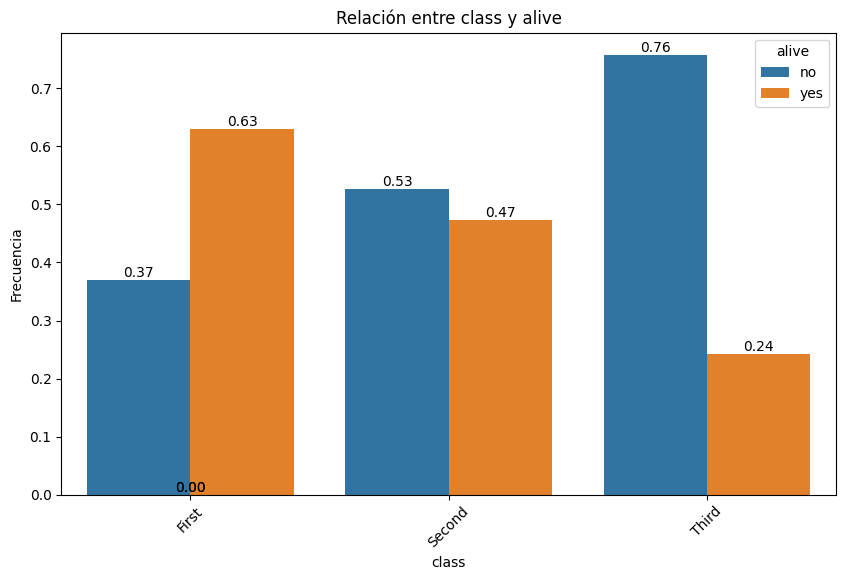

In [10]:
plot_categorical_relationship_fin(df, "class", "alive", show_values=True)
plot_categorical_relationship_fin(df, "class", "alive", relative_freq=True, show_values=True)

In [11]:
tabla = pd.crosstab(df["alive"], df["class"])
chi2, p_value, dof, expected = chi2_contingency(tabla)
print(f"Chi2: {chi2:.2f} | p-value: {p_value:.4f}")
print("¿Relación significativa?", p_value < 0.05)

Chi2: 102.89 | p-value: 0.0000
¿Relación significativa? True


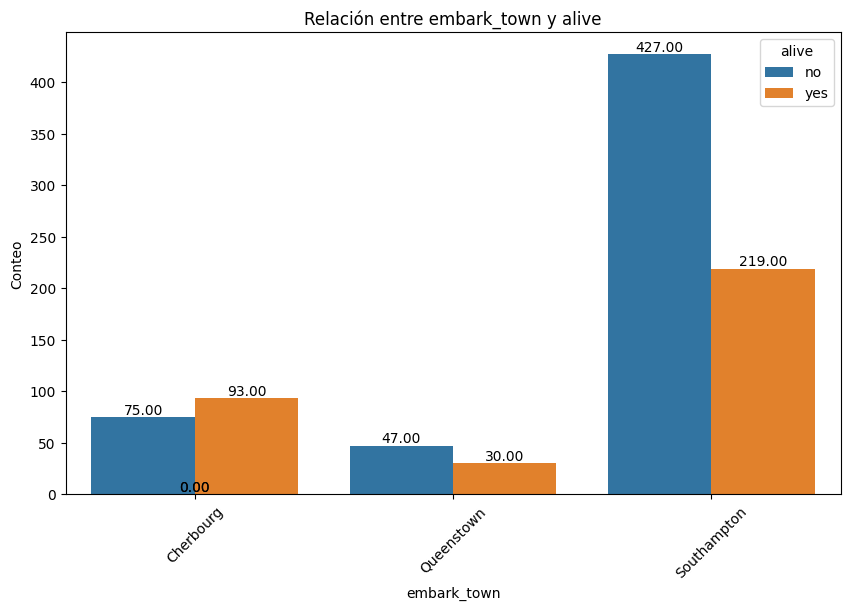

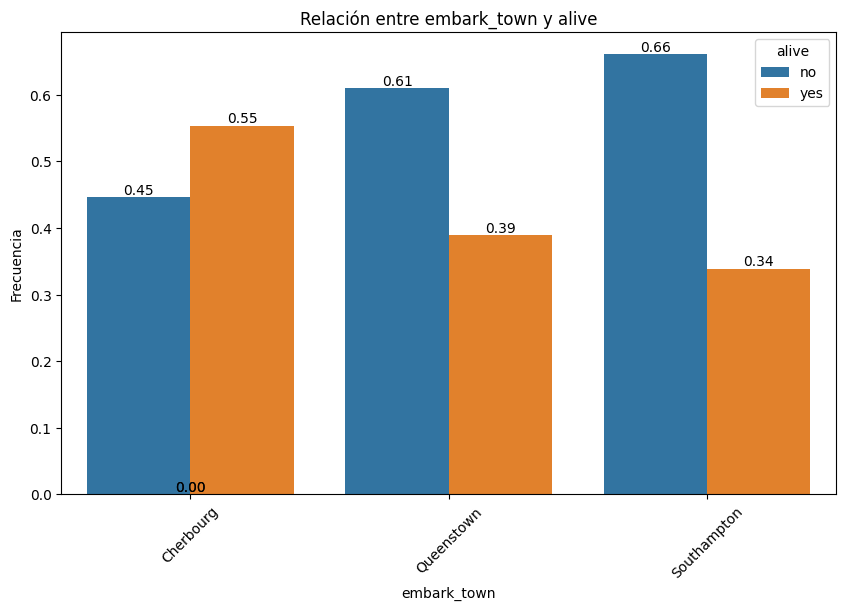

In [12]:
plot_categorical_relationship_fin(df, "embark_town", "alive", show_values=True)
plot_categorical_relationship_fin(df, "embark_town", "alive", relative_freq=True, show_values=True)

In [13]:
tabla = pd.crosstab(df["alive"], df["embark_town"])
chi2, p_value, dof, expected = chi2_contingency(tabla)
print(f"Chi2: {chi2:.2f} | p-value: {p_value:.4f}")
print("¿Relación significativa?", p_value < 0.05)

Chi2: 25.96 | p-value: 0.0000
¿Relación significativa? True


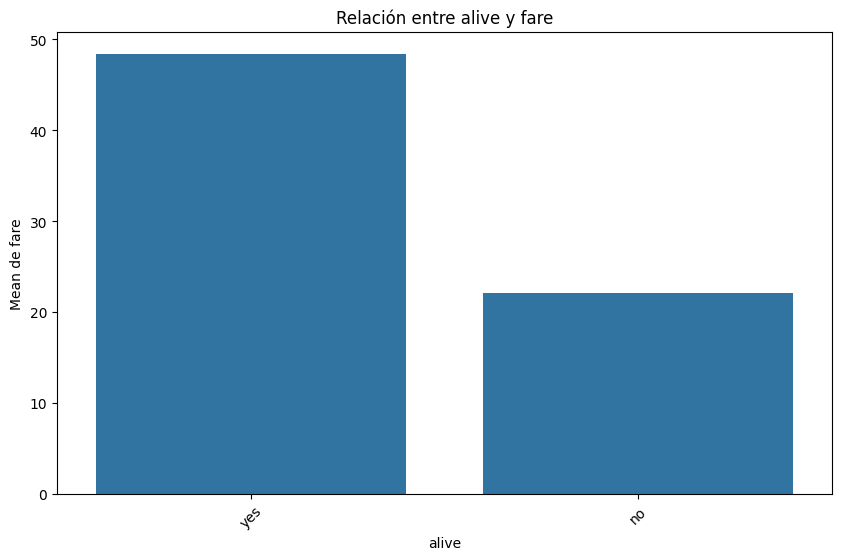

In [14]:
plot_categorical_numerical_relationship(df, "alive", "fare")


In [16]:
grupo_yes = df.loc[df["alive"] == "yes", "fare"]
grupo_no  = df.loc[df["alive"] == "no",  "fare"]
stat, p_value = mannwhitneyu(grupo_yes, grupo_no)
print(f"Estadístico U: {stat:.2f} | p-value: {p_value:.4f}")
print("¿Relación significativa?", p_value < 0.05)

Estadístico U: 129951.50 | p-value: 0.0000
¿Relación significativa? True


In [17]:
print(df[df["fare"] == 0][["who", "class", "embark_town", "alive", "fare"]])


     who   class  embark_town alive  fare
179  man   Third  Southampton    no   0.0
263  man   First  Southampton    no   0.0
271  man   Third  Southampton   yes   0.0
277  man  Second  Southampton    no   0.0
302  man   Third  Southampton    no   0.0
413  man  Second  Southampton    no   0.0
466  man  Second  Southampton    no   0.0
481  man  Second  Southampton    no   0.0
597  man   Third  Southampton    no   0.0
633  man   First  Southampton    no   0.0
674  man  Second  Southampton    no   0.0
732  man  Second  Southampton    no   0.0
806  man   First  Southampton    no   0.0
815  man   First  Southampton    no   0.0
822  man   First  Southampton    no   0.0


In [18]:
max_fare = df["fare"].max()
print(df[df["fare"] == max_fare][["who", "class", "embark_town", "alive", "fare"]])

       who  class embark_town alive      fare
258  woman  First   Cherbourg   yes  512.3292
679    man  First   Cherbourg   yes  512.3292
737    man  First   Cherbourg   yes  512.3292


In [19]:
plot_grouped_boxplots(df, "embark_town", "fare", "alive")


TypeError: plot_grouped_boxplots() takes 3 positional arguments but 4 were given

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?